# Comparación de Welch y wavelets para reconstruir la DSA

## Objetivo

Comparar la reconstrucción espectral de referencia mediante Welch con una
transformada wavelet continua (CWT) Morlet compleja. Las matrices se comparan
frente al archivo espectral original `.f_a` mediante Pearson, MAE y RMSE.

El experimento no modifica la aplicación. Su finalidad es valorar si la mayor
resolución temporal de las wavelets mejora la semejanza con la DSA exportada
por el monitor BIS.

## Condiciones comunes

- C1 para registros unilaterales.
- C1 izquierdo y C3 derecho para registros bilaterales.
- Mismo filtro pasa-altos causal indicado por `LoFilter`.
- Frecuencias entre 0,5 y 30 Hz, separadas 0,5 Hz.
- Representación temporal cada segundo.
- Agregación temporal Hann de 2 s y avance de 1 s.
- Integración de cada densidad espectral en bins de 0,5 Hz.
- Conversión a dB respecto a 0,0001 µV RMS.
- Suavizado causal `rolling` según `SpSmooth`.
- Exclusión de los segundos inválidos durante el suavizado.
- Barrido de desplazamientos entre 0 y 30 s.
- Misma timeline `.spa` y mismas máscaras de calidad.

Se analizan `L03041035` y `L05141322` completos. Del registro de aproximadamente
17 horas `L04301923` se utiliza un tramo inicial de 2 horas, suficiente para
comprobar el comportamiento en una sesión larga sin convertir la CWT en un
proceso de duración excesiva.

## Normalización de la potencia wavelet

La CWT de PyWavelets devuelve coeficientes complejos, no una PSD expresada
directamente en µV²/Hz. Para evitar ajustar artificialmente la wavelet al
`.f_a`, se aplica una calibración independiente:

1. Se calcula la respuesta de cada escala a un impulso unitario.
2. Se obtiene la energía exacta del filtro wavelet discreto.
3. La potencia instantánea se normaliza como:

$$
\widehat{S}(f,t) =
\frac{2|W(f,t)|^2}
{f_s \sum_n |h_f[n]|^2}
$$

Esta expresión hace que, para ruido blanco real de varianza $\sigma^2$, el
valor esperado sea la PSD unilateral $2\sigma^2/f_s$. Después se promedia con
la ventana Hann de 2 s y se integra cada bin multiplicando por 0,5 Hz.

Esta normalización permite interpretar MAE y RMSE en dB, pero no implica que el
monitor BIS utilice wavelets.

In [1]:
from pathlib import Path
import gc
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt
from scipy.signal import get_window

APP_DIR = Path(r"C:\Users\usuario\tfg_app")
if str(APP_DIR) not in sys.path:
    sys.path.insert(0, str(APP_DIR))

from src.lectura_fa import (
    cargar_fa_bilateral_completo_desde_ruta,
    cargar_fa_unilateral_desde_ruta,
)
from src.lectura_spa import (
    cargar_spa_bilateral_desde_ruta,
    cargar_spa_unilateral_desde_ruta,
    preparar_dsa_bilateral_con_spa,
    preparar_dsa_unilateral_con_spa,
    preparar_timeline_spa,
)
import src.reconstruccion as rec

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 170)

In [2]:
REGISTROS = [
    {
        "nombre": "L03041035",
        "modo": "unilateral",
        "duracion_max_s": None,
        "carpeta": Path(
            r"C:\Users\usuario\TFG_BIS_GIS\data\data_bis_advanced"
            r"\M-TA6m-03041035\DH03041035"
        ),
    },
    {
        "nombre": "L05141322",
        "modo": "bilateral",
        "duracion_max_s": None,
        "carpeta": Path(
            r"C:\Users\usuario\TFG_BIS_GIS\data\data_bis_advanced"
            r"\bilateral\L05141322"
        ),
    },
    {
        "nombre": "L04301923",
        "modo": "bilateral",
        "duracion_max_s": 2 * 60 * 60,
        "carpeta": Path(
            r"C:\Users\usuario\TFG_BIS_GIS\data\data_bis_advanced"
            r"\bilateral\M-Py5D-04301923\DH04301923"
        ),
    },
]

BANDWIDTHS = [0.5, 1.5, 3.0, 6.0, 12.0]
SHIFTS = range(0, 31)
FRECUENCIAS = np.arange(0.5, 30.0 + 0.5, 0.5)

for registro in REGISTROS:
    base = registro["carpeta"] / registro["nombre"]
    registro["header"] = base.with_suffix(".h_a")
    registro["ta"] = base.with_suffix(".t_a")
    registro["raw"] = base.with_suffix(
        ".r4a" if registro["modo"] == "bilateral" else ".r2a"
    )
    registro["spa"] = base.with_suffix(".spa")
    registro["fa"] = base.with_suffix(".f_a")

pd.DataFrame(
    [
        {
            "registro": r["nombre"],
            "modo": r["modo"],
            "duracion_analizada_s": r["duracion_max_s"] or "completa",
            "raw_MB": r["raw"].stat().st_size / 1024**2,
        }
        for r in REGISTROS
    ]
).round(2)

,registro,modo,duracion_analizada_s,raw_MB
0,L03041035,unilateral,completa,1.03
1,L05141322,bilateral,completa,2.65
2,L04301923,bilateral,7200,59.46


## Wavelets ensayadas

Se utiliza la familia `cmorB-1.0`. El parámetro central permanece fijo y se
modifica `B`, que controla el compromiso tiempo-frecuencia:

- Valores pequeños: mejor localización temporal y peor resolución frecuencial.
- Valores grandes: mayor resolución frecuencial y más extensión temporal.

Se aplica una máscara común en los extremos correspondiente a cuatro
desviaciones típicas de la wavelet más extensa y de la frecuencia mínima. Así
se evita beneficiar o perjudicar a un método por efectos de borde.

In [3]:
def limitar_spa(df_spa, duracion_max_s):
    if duracion_max_s is None:
        return df_spa
    timeline = rec.preparar_timeline_spa(
        df_spa,
        resolver_duplicados="last",
    )
    fin = timeline.iloc[0] + pd.Timedelta(seconds=duracion_max_s - 1)
    return df_spa.loc[df_spa["Time"] <= fin].copy()


def cargar_referencia_fa(config, df_spa):
    if config["modo"] == "unilateral":
        tiempo, _, dsa = cargar_fa_unilateral_desde_ruta(config["fa"])
        dsa, _, mascara = preparar_dsa_unilateral_con_spa(
            tiempo,
            dsa,
            df_spa,
        )
        return {
            "unilateral": {
                "dsa": dsa,
                "mascara_fa": mascara,
                "canal": 0,
                "sqi": "SQI10",
                "totpow": "TOTPOW08",
            }
        }

    tiempo, _, izquierda, derecha = (
        cargar_fa_bilateral_completo_desde_ruta(config["fa"])
    )
    (
        _,
        izquierda,
        derecha,
        _,
        _,
        _,
        mascara_izq,
        mascara_der,
    ) = preparar_dsa_bilateral_con_spa(
        tiempo,
        izquierda,
        derecha,
        df_spa,
    )
    return {
        "izquierda": {
            "dsa": izquierda,
            "mascara_fa": mascara_izq,
            "canal": 0,
            "sqi": "SQI10_izq",
            "totpow": "TOTPOW08_izq",
        },
        "derecha": {
            "dsa": derecha,
            "mascara_fa": mascara_der,
            "canal": 2,
            "sqi": "SQI10_der",
            "totpow": "TOTPOW08_der",
        },
    }


def mascara_cono_influencia(longitud, frecuencia_minima=0.5):
    # Para cmorB-C, sigma de la envolvente de potencia:
    # sigma_t = sqrt(B) / (2 f). Se enmascaran cuatro sigmas.
    segundos = int(
        np.ceil(
            2
            * np.sqrt(max(BANDWIDTHS))
            / frecuencia_minima
        )
    )
    mascara = pd.Series(False, index=range(longitud))
    mascara.iloc[:segundos] = True
    mascara.iloc[-segundos:] = True
    return mascara, segundos


def calibracion_filtros_wavelet(wavelet, escalas, fs):
    semisoporte = int(
        np.ceil(
            max(abs(wavelet.lower_bound), abs(wavelet.upper_bound))
            * np.max(escalas)
        )
    )
    impulso = np.zeros(2 * semisoporte + 1, dtype=float)
    impulso[semisoporte] = 1.0
    coeficientes, _ = pywt.cwt(
        impulso,
        escalas,
        wavelet,
        sampling_period=1 / fs,
        method="fft",
    )
    return np.sum(np.abs(coeficientes) ** 2, axis=1)


def calcular_dsa_wavelet(
    senal,
    fs,
    bandwidth,
    parametros,
    timeline,
    lote=4,
):
    wavelet = pywt.ContinuousWavelet(f"cmor{bandwidth}-1.0")
    escalas = pywt.frequency2scale(
        wavelet,
        FRECUENCIAS / fs,
    )
    energias = calibracion_filtros_wavelet(
        wavelet,
        escalas,
        fs,
    )

    nperseg = int(parametros["ventana_welch_s"] * fs)
    paso = int(parametros["paso_welch_s"] * fs)
    inicios = np.arange(
        0,
        len(senal) - nperseg + 1,
        paso,
        dtype=np.int64,
    )
    indices = np.arange(nperseg, dtype=np.int64)
    hann = get_window("hann", nperseg, fftbins=True)
    hann = hann / hann.sum()

    # Los NaN se sustituyen solo para poder ejecutar la convolución.
    # Las ventanas afectadas quedan invalidadas mediante la máscara raw.
    senal_cwt = np.nan_to_num(senal, nan=0.0)
    psd_epocas = np.empty(
        (len(inicios), len(FRECUENCIAS)),
        dtype=float,
    )

    for inicio_lote in range(0, len(FRECUENCIAS), lote):
        fin_lote = min(inicio_lote + lote, len(FRECUENCIAS))
        coeficientes, _ = pywt.cwt(
            senal_cwt,
            escalas[inicio_lote:fin_lote],
            wavelet,
            sampling_period=1 / fs,
            method="fft",
        )
        psd_instantanea = (
            2
            * np.abs(coeficientes) ** 2
            / (
                fs
                * energias[inicio_lote:fin_lote, None]
            )
        )
        segmentos = psd_instantanea[
            :,
            inicios[:, None] + indices,
        ]
        psd_epocas[:, inicio_lote:fin_lote] = np.einsum(
            "bni,i->nb",
            segmentos,
            hann,
            optimize=True,
        )

    tiempos_s = (inicios + nperseg / 2) / fs
    dsa_db = rec._convertir_potencia_a_db(
        psd_epocas,
        parametros,
    )
    return rec._ajustar_reconstruida_a_timeline(
        dsa_db,
        FRECUENCIAS,
        tiempos_s,
        timeline,
    ), tiempos_s

In [4]:
def suavizar_solo_validos(dsa, mascara, ventana_s):
    trabajo = dsa.copy()
    trabajo.loc[pd.Series(mascara).to_numpy(dtype=bool), :] = np.nan
    if ventana_s > 1:
        return trabajo.rolling(
            window=int(ventana_s),
            min_periods=1,
            center=False,
        ).mean()
    return trabajo


def metricas_con_shift(referencia, suavizada, mascara_destino, shift_s):
    ref = np.asarray(referencia, dtype=float)
    candidata = np.asarray(suavizada, dtype=float)
    mascara_destino = np.asarray(mascara_destino, dtype=bool)

    if shift_s > 0:
        ref = ref[shift_s:, :]
        candidata = candidata[:-shift_s, :]
        mascara_destino = mascara_destino[shift_s:]

    validos = (
        np.isfinite(ref)
        & np.isfinite(candidata)
        & (~mascara_destino[:, None])
    )
    a = ref[validos]
    b = candidata[validos]
    return {
        "n": len(a),
        "Pearson": float(np.corrcoef(a, b)[0, 1]),
        "MAE": float(np.mean(np.abs(a - b))),
        "RMSE": float(np.sqrt(np.mean((a - b) ** 2))),
        "bias": float(np.mean(b - a)),
    }


def evaluar_matriz(
    resultados,
    config,
    lado,
    metodo,
    parametro_wavelet,
    referencia,
    dsa,
    mascara,
    suavizado_s,
):
    suavizada = suavizar_solo_validos(
        dsa,
        mascara,
        suavizado_s,
    )
    for shift_s in SHIFTS:
        resultados.append(
            {
                "registro": config["nombre"],
                "modo": config["modo"],
                "lado": lado,
                "metodo": metodo,
                "bandwidth_B": parametro_wavelet,
                "SpSmooth_s": suavizado_s,
                "shift_s": shift_s,
                **metricas_con_shift(
                    referencia,
                    suavizada,
                    mascara,
                    shift_s,
                ),
            }
        )

In [5]:
def procesar_registro(config):
    cargar_spa = (
        cargar_spa_bilateral_desde_ruta
        if config["modo"] == "bilateral"
        else cargar_spa_unilateral_desde_ruta
    )
    df_spa = limitar_spa(
        cargar_spa(config["spa"]),
        config["duracion_max_s"],
    )
    timeline = preparar_timeline_spa(
        df_spa,
        resolver_duplicados="last",
    )
    header = rec.extraer_parametros_eeg_desde_ruta(config["header"])
    raw = rec._leer_raw_intercalado_desde_ruta(
        config["raw"],
        header["num_canales"],
    )
    alineacion = rec._calcular_indices_alineacion(
        rec.leer_inicio_ta_desde_ruta(config["ta"]),
        timeline,
        header["fs"],
        len(raw),
    )
    codigo_spsmooth, suavizado_s = rec._extraer_suavizado_spsmooth(
        df_spa
    )
    codigo_lofilter, frecuencia_lofilter, _ = (
        rec._extraer_filtro_lofilter(
            df_spa,
            rec.PARAMETROS_RECONSTRUCCION[
                "filtro_pasa_altos_predeterminado_hz"
            ],
        )
    )
    parametros = dict(rec.PARAMETROS_RECONSTRUCCION)
    parametros["filtro_pasa_altos_hz"] = frecuencia_lofilter
    df_merge = rec._alinear_spa(timeline, df_spa)
    referencias = cargar_referencia_fa(config, df_spa)
    mascara_bordes, segundos_borde = mascara_cono_influencia(
        len(timeline)
    )

    resultados = []
    diagnosticos = []

    for lado, datos_lado in referencias.items():
        canal = datos_lado["canal"]
        senal = rec._canal_alineado_uv(
            raw,
            canal,
            header["pendiente"],
            header["offset"],
            alineacion,
        )
        senal = rec._filtrar_pasa_altos_causal(
            senal,
            header["fs"],
            frecuencia_lofilter,
            parametros["orden_filtro_pasa_altos"],
        )

        psd_welch, frecuencias_welch, tiempos_welch = (
            rec._welch_por_bloques(
                senal,
                header["fs"],
                parametros["ventana_welch_s"],
                parametros["paso_welch_s"],
                parametros["fmin"],
                parametros["fmax"],
                parametros["paso_frecuencia"],
                "densidad",
                "centro",
            )
        )
        dsa_welch = rec._ajustar_reconstruida_a_timeline(
            rec._convertir_potencia_a_db(psd_welch, parametros),
            frecuencias_welch,
            tiempos_welch,
            timeline,
        )
        mascara_raw, diagnostico_raw = (
            rec._crear_mascara_raw_para_canal(
                raw,
                canal,
                alineacion,
                parametros,
                tiempos_welch,
                timeline,
            )
        )

        mascara_welch = (
            rec._crear_mascara(
                timeline,
                dsa_welch,
                df_merge[datos_lado["sqi"]],
                df_merge[datos_lado["totpow"]],
                parametros["umbral_sqi"],
                parametros["umbral_ceros"],
            )
            | mascara_raw
            | mascara_bordes
        )
        evaluar_matriz(
            resultados,
            config,
            lado,
            "Welch",
            np.nan,
            datos_lado["dsa"],
            dsa_welch,
            mascara_welch,
            suavizado_s,
        )

        for bandwidth in BANDWIDTHS:
            inicio = time.perf_counter()
            dsa_wavelet, _ = calcular_dsa_wavelet(
                senal,
                header["fs"],
                bandwidth,
                parametros,
                timeline,
            )
            mascara_wavelet = (
                rec._crear_mascara(
                    timeline,
                    dsa_wavelet,
                    df_merge[datos_lado["sqi"]],
                    df_merge[datos_lado["totpow"]],
                    parametros["umbral_sqi"],
                    parametros["umbral_ceros"],
                )
                | mascara_raw
                | mascara_bordes
            )
            evaluar_matriz(
                resultados,
                config,
                lado,
                "CWT Morlet",
                bandwidth,
                datos_lado["dsa"],
                dsa_wavelet,
                mascara_wavelet,
                suavizado_s,
            )
            diagnosticos.append(
                {
                    "registro": config["nombre"],
                    "lado": lado,
                    "bandwidth_B": bandwidth,
                    "segundos_analizados": len(timeline),
                    "segundos_borde_por_extremo": segundos_borde,
                    "tiempo_calculo_s": (
                        time.perf_counter() - inicio
                    ),
                    "mediana_dB": float(
                        np.nanmedian(dsa_wavelet.to_numpy())
                    ),
                    "ventanas_raw_invalidas": diagnostico_raw[
                        "ventanas_welch_afectadas"
                    ],
                    "SpSmooth_s": suavizado_s,
                    "LoFilter_codigo": codigo_lofilter,
                    "LoFilter_Hz": frecuencia_lofilter,
                }
            )
            del dsa_wavelet
            gc.collect()

    return resultados, diagnosticos

## Ejecución

In [6]:
resultados = []
diagnosticos = []

for config in REGISTROS:
    print(
        f"Procesando {config['nombre']} ({config['modo']})...",
        flush=True,
    )
    res, diag = procesar_registro(config)
    resultados.extend(res)
    diagnosticos.extend(diag)
    gc.collect()

df_resultados = pd.DataFrame(resultados)
df_diagnosticos = pd.DataFrame(diagnosticos)

print(f"Combinaciones método/shift evaluadas: {len(df_resultados):,}")
print(f"Configuraciones wavelet ejecutadas: {len(df_diagnosticos)}")

Procesando L03041035 (unilateral)...
Procesando L05141322 (bilateral)...
Procesando L04301923 (bilateral)...
Combinaciones método/shift evaluadas: 930
Configuraciones wavelet ejecutadas: 25


## Diagnóstico de las configuraciones wavelet

In [7]:
display(
    df_diagnosticos.round(4).sort_values(
        ["registro", "lado", "bandwidth_B"]
    )
)

,registro,lado,bandwidth_B,segundos_analizados,segundos_borde_por_extremo,tiempo_calculo_s,mediana_dB,ventanas_raw_invalidas,SpSmooth_s,LoFilter_codigo,LoFilter_Hz
0,L03041035,unilateral,0.5,2119,14,5.3482,85.0830,0,30,3,2.5
1,L03041035,unilateral,1.5,2119,14,4.4377,84.4481,0,30,3,2.5
2,L03041035,unilateral,3.0,2119,14,3.6518,84.3233,0,30,3,2.5
3,L03041035,unilateral,6.0,2119,14,4.3382,84.2539,0,30,3,2.5
4,L03041035,unilateral,12.0,2119,14,4.7524,84.2046,0,30,3,2.5
20,L04301923,derecha,0.5,7200,14,14.7539,70.9731,0,30,3,2.5
21,L04301923,derecha,1.5,7200,14,15.5636,70.0116,0,30,3,2.5
22,L04301923,derecha,3.0,7200,14,15.6730,69.6997,0,30,3,2.5
23,L04301923,derecha,6.0,7200,14,15.6297,69.4528,0,30,3,2.5
24,L04301923,derecha,12.0,7200,14,15.9622,69.2307,0,30,3,2.5


## Mejor shift según Pearson

In [8]:
mejores_pearson = (
    df_resultados
    .sort_values(
        [
            "registro",
            "lado",
            "metodo",
            "bandwidth_B",
            "Pearson",
            "RMSE",
        ],
        ascending=[True, True, True, True, False, True],
        na_position="first",
    )
    .groupby(
        ["registro", "lado", "metodo", "bandwidth_B"],
        dropna=False,
        as_index=False,
    )
    .first()
)
display(mejores_pearson)

,registro,lado,metodo,bandwidth_B,modo,SpSmooth_s,shift_s,n,Pearson,MAE,RMSE,bias
0,L03041035,unilateral,CWT Morlet,0.5,unilateral,30,11,116220,0.690950,5.976071,7.119757,5.873828
1,L03041035,unilateral,CWT Morlet,1.5,unilateral,30,11,116220,0.707219,5.408078,6.603247,5.272846
2,L03041035,unilateral,CWT Morlet,3.0,unilateral,30,11,116220,0.709383,5.278050,6.497111,5.132440
3,L03041035,unilateral,CWT Morlet,6.0,unilateral,30,11,116220,0.708007,5.190712,6.445226,5.035723
4,L03041035,unilateral,CWT Morlet,12.0,unilateral,30,11,116220,0.703656,5.117820,6.424436,4.951394
5,L03041035,unilateral,Welch,NaN,unilateral,30,10,116340,0.723813,3.720290,5.032721,2.957049
6,L04301923,derecha,CWT Morlet,0.5,bilateral,30,6,429960,0.974748,4.108021,4.495418,3.710798
7,L04301923,derecha,CWT Morlet,1.5,bilateral,30,6,429960,0.975597,3.061854,3.426845,2.607090
8,L04301923,derecha,CWT Morlet,3.0,bilateral,30,6,429960,0.975913,2.769705,3.145625,2.289971
9,L04301923,derecha,CWT Morlet,6.0,bilateral,30,6,429960,0.976002,2.569771,2.961578,2.066681


## Ganador por registro y lado

Se selecciona para cada método su configuración con mayor Pearson. La tabla
permite comparar directamente Welch con la mejor wavelet encontrada.

In [9]:
ganadores_metodo = (
    mejores_pearson
    .sort_values(
        ["registro", "lado", "metodo", "Pearson", "RMSE"],
        ascending=[True, True, True, False, True],
    )
    .groupby(
        ["registro", "lado", "metodo"],
        as_index=False,
    )
    .first()
)
display(ganadores_metodo)

,registro,lado,metodo,bandwidth_B,modo,SpSmooth_s,shift_s,n,Pearson,MAE,RMSE,bias
0,L03041035,unilateral,CWT Morlet,3.0,unilateral,30,11,116220,0.709383,5.278050,6.497111,5.132440
1,L03041035,unilateral,Welch,NaN,unilateral,30,10,116340,0.723813,3.720290,5.032721,2.957049
2,L04301923,derecha,CWT Morlet,6.0,bilateral,30,6,429960,0.976002,2.569771,2.961578,2.066681
3,L04301923,derecha,Welch,NaN,bilateral,30,6,429960,0.982967,1.021534,1.598269,0.122782
4,L04301923,izquierda,CWT Morlet,6.0,bilateral,30,6,429780,0.978836,2.500513,2.839930,1.942078
5,L04301923,izquierda,Welch,NaN,bilateral,30,6,429780,0.983623,0.993570,1.577253,-0.021439
6,L05141322,derecha,CWT Morlet,12.0,bilateral,30,6,160680,0.939981,2.936427,3.475736,2.632695
7,L05141322,derecha,Welch,NaN,bilateral,30,6,160680,0.945502,1.746017,2.387310,0.873343
8,L05141322,izquierda,CWT Morlet,12.0,bilateral,30,6,153780,0.937658,2.660574,3.199339,2.332528
9,L05141322,izquierda,Welch,NaN,bilateral,30,6,153780,0.938839,1.600414,2.307587,0.520751


## Mejor configuración según RMSE

In [10]:
mejores_rmse = (
    df_resultados
    .sort_values(
        [
            "registro",
            "lado",
            "metodo",
            "RMSE",
            "Pearson",
        ],
        ascending=[True, True, True, True, False],
    )
    .groupby(
        ["registro", "lado", "metodo"],
        as_index=False,
    )
    .first()
)
display(mejores_rmse)

,registro,lado,metodo,modo,bandwidth_B,SpSmooth_s,shift_s,n,Pearson,MAE,RMSE,bias
0,L03041035,unilateral,CWT Morlet,unilateral,12.0,30,12,116100,0.703156,5.119240,6.423438,4.948366
1,L03041035,unilateral,Welch,unilateral,NaN,30,11,116220,0.723603,3.726136,5.031350,2.954597
2,L04301923,derecha,CWT Morlet,bilateral,12.0,30,6,429960,0.975535,2.410172,2.827693,1.886161
3,L04301923,derecha,Welch,bilateral,NaN,30,6,429960,0.982967,1.021534,1.598269,0.122782
4,L04301923,izquierda,CWT Morlet,bilateral,12.0,30,6,429780,0.977959,2.351326,2.721497,1.784450
5,L04301923,izquierda,Welch,bilateral,NaN,30,6,429780,0.983623,0.993570,1.577253,-0.021439
6,L05141322,derecha,CWT Morlet,bilateral,12.0,30,6,160680,0.939981,2.936427,3.475736,2.632695
7,L05141322,derecha,Welch,bilateral,NaN,30,6,160680,0.945502,1.746017,2.387310,0.873343
8,L05141322,izquierda,CWT Morlet,bilateral,12.0,30,6,153780,0.937658,2.660574,3.199339,2.332528
9,L05141322,izquierda,Welch,bilateral,NaN,30,6,153780,0.938839,1.600414,2.307587,0.520751


## Influencia del parámetro de ancho wavelet

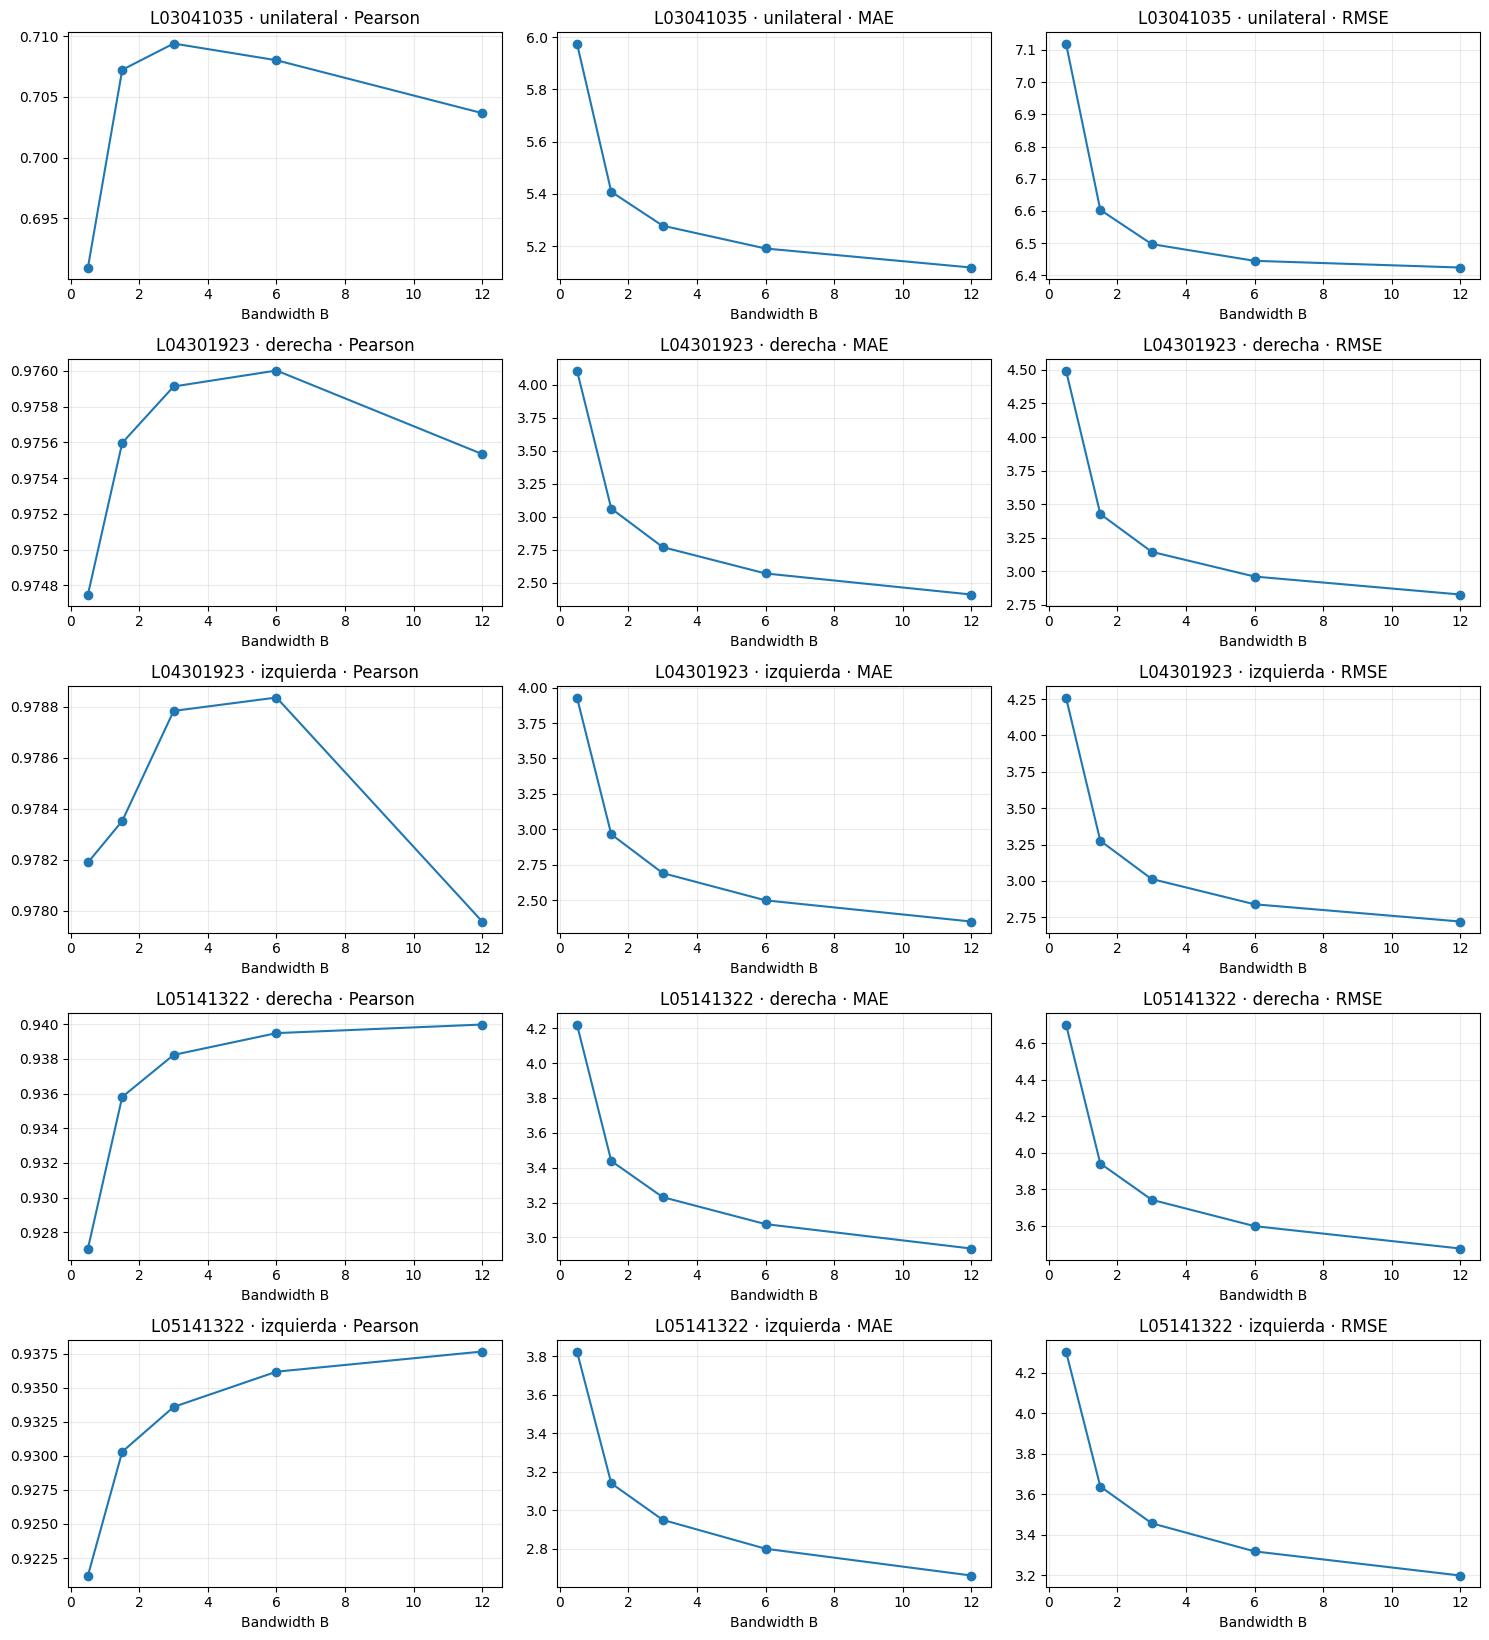

In [11]:
solo_wavelet = mejores_pearson.loc[
    mejores_pearson["metodo"] == "CWT Morlet"
].copy()

grupos = list(solo_wavelet.groupby(["registro", "lado"]))
fig, axes = plt.subplots(
    len(grupos),
    3,
    figsize=(15, 3.3 * len(grupos)),
    squeeze=False,
)

for fila, ((registro, lado), grupo) in enumerate(grupos):
    grupo = grupo.sort_values("bandwidth_B")
    axes[fila, 0].plot(
        grupo["bandwidth_B"],
        grupo["Pearson"],
        marker="o",
    )
    axes[fila, 1].plot(
        grupo["bandwidth_B"],
        grupo["MAE"],
        marker="o",
    )
    axes[fila, 2].plot(
        grupo["bandwidth_B"],
        grupo["RMSE"],
        marker="o",
    )
    axes[fila, 0].set_title(f"{registro} · {lado} · Pearson")
    axes[fila, 1].set_title(f"{registro} · {lado} · MAE")
    axes[fila, 2].set_title(f"{registro} · {lado} · RMSE")
    for columna in range(3):
        axes[fila, columna].set_xlabel("Bandwidth B")
        axes[fila, columna].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Comparación de los shifts

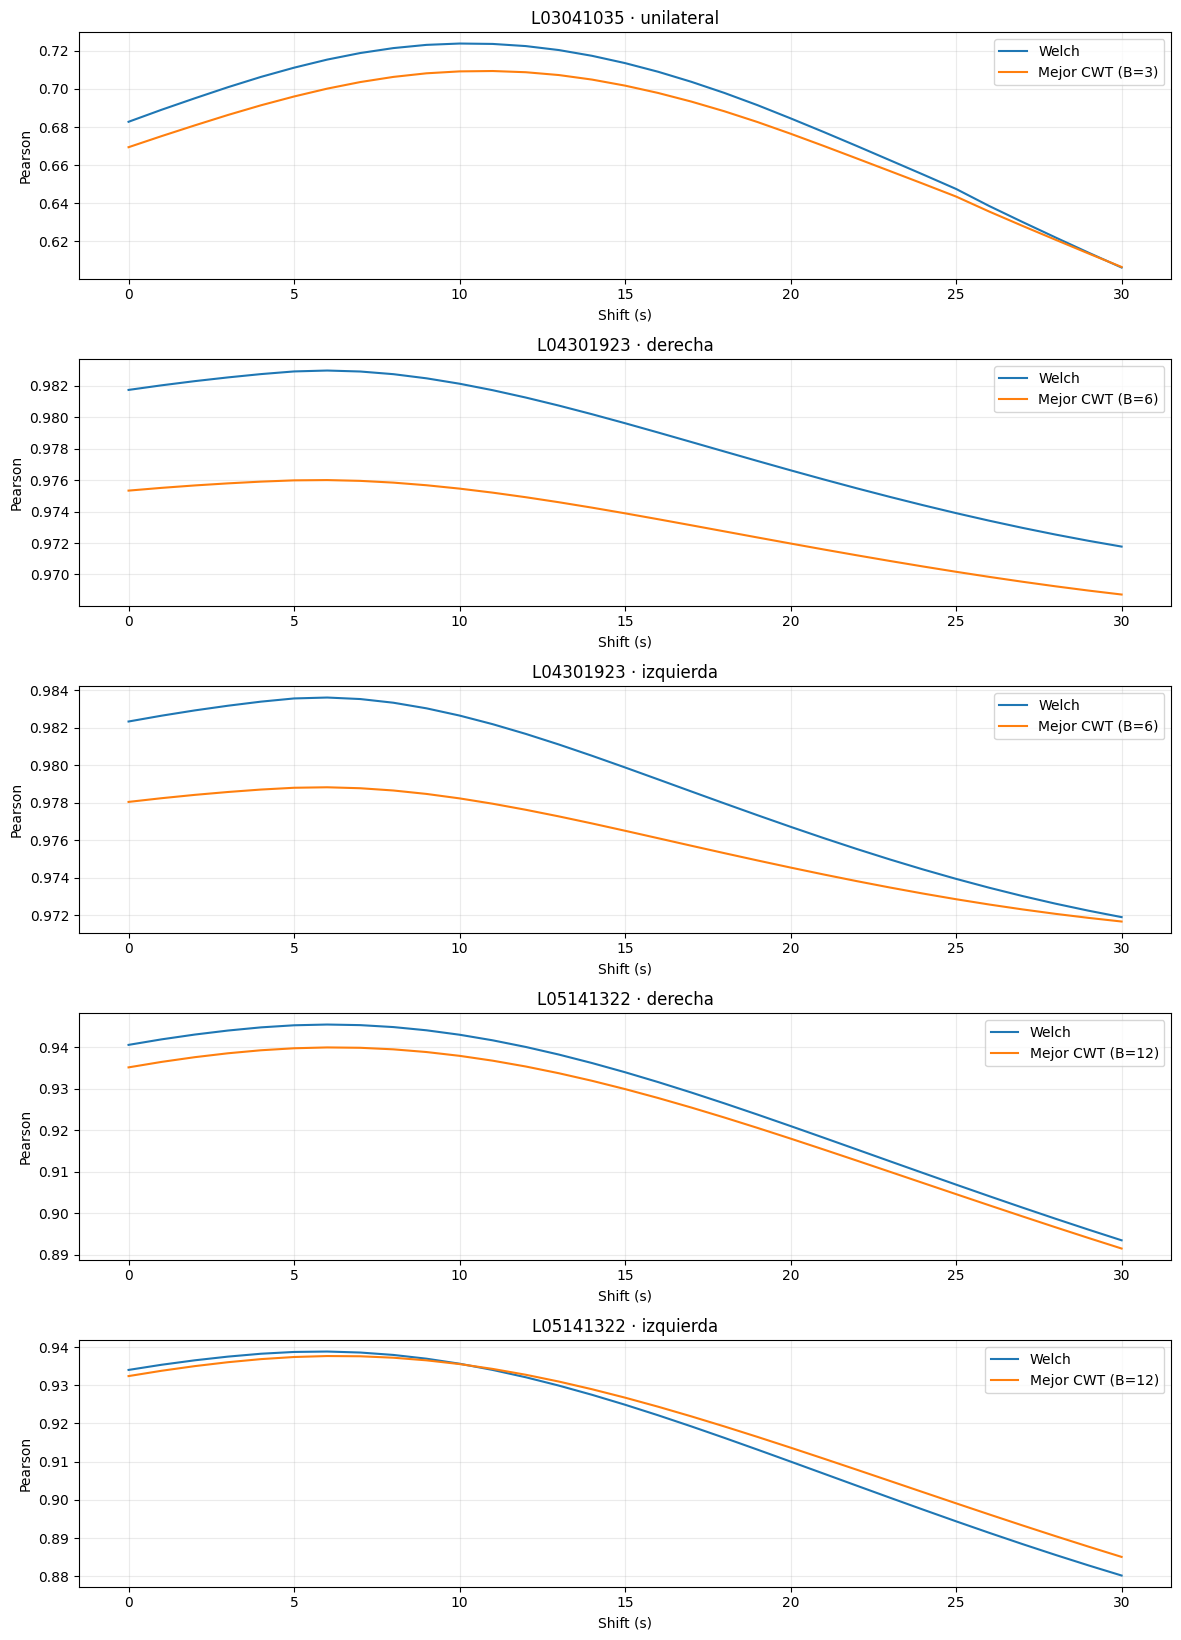

In [12]:
fig, axes = plt.subplots(
    len(grupos),
    1,
    figsize=(12, 3.3 * len(grupos)),
    squeeze=False,
)

for fila, ((registro, lado), _) in enumerate(grupos):
    datos = df_resultados.loc[
        (df_resultados["registro"] == registro)
        & (df_resultados["lado"] == lado)
    ]
    ganador_wavelet = ganadores_metodo.loc[
        (ganadores_metodo["registro"] == registro)
        & (ganadores_metodo["lado"] == lado)
        & (ganadores_metodo["metodo"] == "CWT Morlet")
    ].iloc[0]

    welch = datos.loc[datos["metodo"] == "Welch"]
    wavelet = datos.loc[
        (datos["metodo"] == "CWT Morlet")
        & (
            datos["bandwidth_B"]
            == ganador_wavelet["bandwidth_B"]
        )
    ]
    axes[fila, 0].plot(
        welch["shift_s"],
        welch["Pearson"],
        label="Welch",
    )
    axes[fila, 0].plot(
        wavelet["shift_s"],
        wavelet["Pearson"],
        label=(
            "Mejor CWT "
            f"(B={ganador_wavelet['bandwidth_B']:g})"
        ),
    )
    axes[fila, 0].set_title(f"{registro} · {lado}")
    axes[fila, 0].set_xlabel("Shift (s)")
    axes[fila, 0].set_ylabel("Pearson")
    axes[fila, 0].grid(alpha=0.25)
    axes[fila, 0].legend()

plt.tight_layout()
plt.show()

## Exportación

In [13]:
SALIDA = Path.cwd()
df_resultados.to_csv(
    SALIDA / "resultados_welch_wavelets.csv",
    index=False,
)
df_diagnosticos.to_csv(
    SALIDA / "diagnostico_wavelets.csv",
    index=False,
)
mejores_pearson.to_csv(
    SALIDA / "mejores_shifts_welch_wavelets.csv",
    index=False,
)
ganadores_metodo.to_csv(
    SALIDA / "ganadores_welch_wavelets.csv",
    index=False,
)

print("Resultados exportados.")

Resultados exportados.


## Conclusión automática

In [14]:
comparacion = ganadores_metodo.pivot_table(
    index=["registro", "lado"],
    columns="metodo",
    values=["Pearson", "MAE", "RMSE"],
)
comparacion["delta_Pearson_CWT_menos_Welch"] = (
    comparacion[("Pearson", "CWT Morlet")]
    - comparacion[("Pearson", "Welch")]
)
comparacion["delta_MAE_CWT_menos_Welch"] = (
    comparacion[("MAE", "CWT Morlet")]
    - comparacion[("MAE", "Welch")]
)
comparacion["delta_RMSE_CWT_menos_Welch"] = (
    comparacion[("RMSE", "CWT Morlet")]
    - comparacion[("RMSE", "Welch")]
)
display(comparacion)

mejora_pearson = (
    comparacion["delta_Pearson_CWT_menos_Welch"] > 0
).sum()
mejora_rmse = (
    comparacion["delta_RMSE_CWT_menos_Welch"] < 0
).sum()

print(
    f"La mejor CWT mejora Pearson en {mejora_pearson} de "
    f"{len(comparacion)} lados analizados."
)
print(
    f"La mejor CWT reduce RMSE en {mejora_rmse} de "
    f"{len(comparacion)} lados analizados."
)

MAE              Pearson                 RMSE           delta_Pearson_CWT_menos_Welch delta_MAE_CWT_menos_Welch delta_RMSE_CWT_menos_Welch
metodo               CWT Morlet     Welch CWT Morlet     Welch CWT Morlet     Welch                                                                                   
registro  lado                                                                                                                                                        
L03041035 unilateral   5.278050  3.720290   0.709383  0.723813   6.497111  5.032721                     -0.014430                  1.557759                   1.464390
L04301923 derecha      2.569771  1.021534   0.976002  0.982967   2.961578  1.598269                     -0.006965                  1.548237                   1.363309
          izquierda    2.500513  0.993570   0.978836  0.983623   2.839930  1.577253                     -0.004787                  1.506943                   1.262677
L05141322 derecha      2.936427  1.746017   0.939981  0.945502   3.475736  2.387310                     -0.005521                  1.190410                   1.088426
          izquierda    2.660574  1.600414   0.937658  0.938839   3.199339  2.307587                     -0.001180                  1.060160                   0.891752

La mejor CWT mejora Pearson en 0 de 5 lados analizados.
La mejor CWT reduce RMSE en 0 de 5 lados analizados.


## Criterio de interpretación

Las wavelets serían preferibles si mostraran una mejora consistente de Pearson
y una reducción de MAE/RMSE en registros y hemisferios diferentes. Una mejora
aislada asociada a un único parámetro no justificaría sustituir el método
espectral, especialmente porque:

- La DSA del monitor está organizada como espectro de potencia por bins.
- Welch proporciona directamente una PSD con unidades físicas definidas.
- La potencia CWT necesita una normalización adicional.
- La ventaja principal de las wavelets es localizar transitorios, no reproducir
  necesariamente una matriz espectral suavizada por el monitor.